In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [6]:
#Creating dataset
X  = 6*np.random.rand(100,1) -3
#Quadratic equation used = y = 0.5x^2 +1.5x +2 +outliers
y = 0.5 * X**2 + 1.5*X +2 + np.random.randn(100,1)


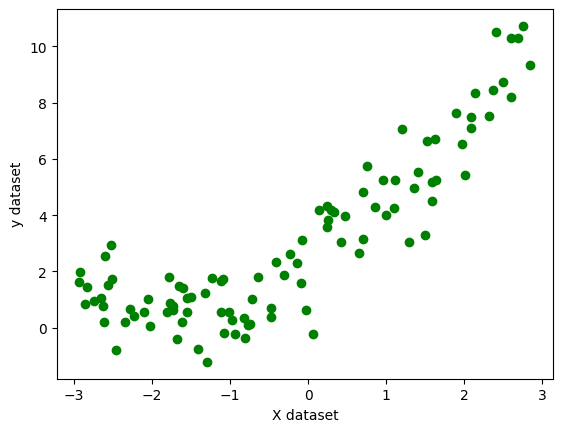

In [7]:
plt.scatter(X,y,color = 'g')
plt.xlabel('X dataset')
plt.ylabel('y dataset')
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [9]:
##Let's implement Simple Linear Regression
from sklearn.linear_model import LinearRegression
regression_1 = LinearRegression()
regression_1.fit(X_train,y_train)

LinearRegression()

In [10]:
from sklearn.metrics import r2_score
score = r2_score(y_test,regression_1.predict(X_test))
score

0.6015223663289654

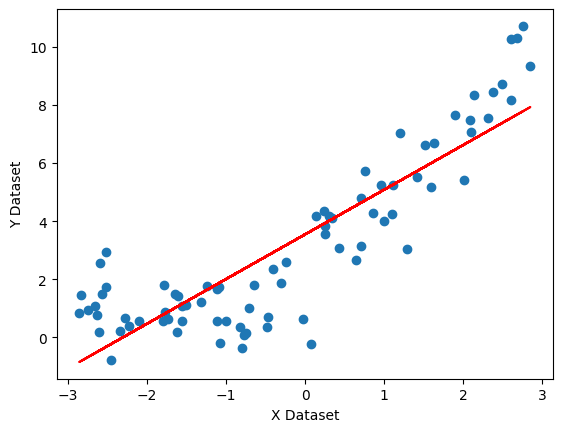

In [11]:
#Let's visulaize  this model
plt.plot(X_train,regression_1.predict(X_train),color = 'r')
plt.scatter(X_train,y_train)
plt.xlabel('X Dataset')
plt.ylabel('Y Dataset')
plt.show()

In [12]:
# Let's Apply polynomial Transformation
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree = 2,include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [13]:
print(X_train.shape,X_train_poly.shape)

(80, 1) (80, 3)


In [14]:
X_train_poly

array([[ 1.00000000e+00,  2.68642563e+00,  7.21688268e+00],
       [ 1.00000000e+00,  2.40094813e-01,  5.76455194e-02],
       [ 1.00000000e+00,  1.11252517e+00,  1.23771225e+00],
       [ 1.00000000e+00,  2.45094053e-01,  6.00710946e-02],
       [ 1.00000000e+00,  7.54526197e-01,  5.69309782e-01],
       [ 1.00000000e+00, -4.10775519e-01,  1.68736527e-01],
       [ 1.00000000e+00,  1.09913872e+00,  1.20810593e+00],
       [ 1.00000000e+00,  2.60282156e+00,  6.77468005e+00],
       [ 1.00000000e+00, -2.75114702e+00,  7.56880994e+00],
       [ 1.00000000e+00, -1.78107258e+00,  3.17221954e+00],
       [ 1.00000000e+00, -2.22582678e+00,  4.95430488e+00],
       [ 1.00000000e+00,  9.55051099e-01,  9.12122601e-01],
       [ 1.00000000e+00,  1.62719628e+00,  2.64776773e+00],
       [ 1.00000000e+00, -2.85763651e+00,  8.16608644e+00],
       [ 1.00000000e+00, -7.48185338e-01,  5.59781300e-01],
       [ 1.00000000e+00, -1.23694065e+00,  1.53002217e+00],
       [ 1.00000000e+00, -2.34636255e+00

In [15]:
from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly,y_train)
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test,y_pred)
print(score)

0.8264368589429906


In [16]:
print(regression.coef_)
print(regression.intercept_)

[[0.         1.61550284 0.41880745]]
[2.34852558]


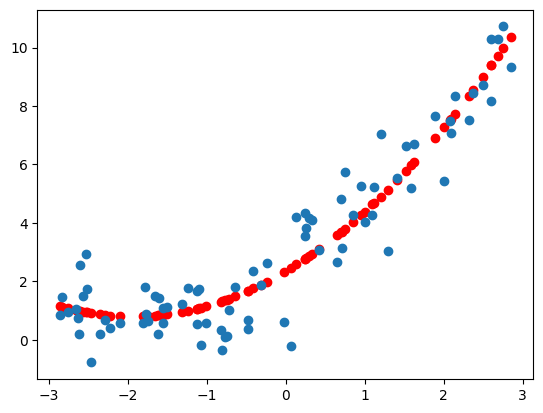

In [17]:
plt.scatter(X_train,regression.predict(X_train_poly),color = 'r')
plt.scatter(X_train,y_train)

In [18]:
## Prediction of new dataset
X_new = np.linspace(X.min(), X.max(), 200).reshape(200,1)
X_new_poly = poly.transform(X_new)
y_new = regression.predict(X_new_poly)

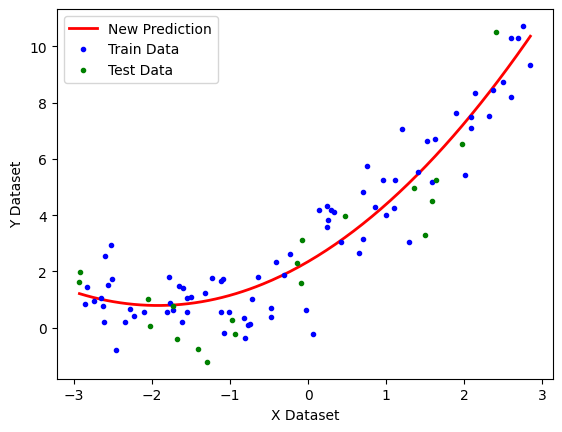

In [19]:
plt.plot(X_new,y_new,"r-",linewidth =2, label = "New Prediction")
plt.plot(X_train,y_train,'b.',label = "Train Data")
plt.plot(X_test,y_test,'g.',label = "Test Data")
plt.xlabel('X Dataset')
plt.ylabel('Y Dataset')
plt.legend()
plt.show()

## Pipeline Concepts

In [20]:
from sklearn.pipeline import Pipeline

In [21]:
def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)

    poly_features=PolynomialFeatures(degree=degree,include_bias=True)
    lin_reg=LinearRegression()
    poly_regression=Pipeline([
        ("poly_features",poly_features),
        ("lin_reg",lin_reg)
    ])
    poly_regression.fit(X_train,y_train) ## ploynomial and fit of linear reression
    y_pred_new=poly_regression.predict(X_new)
    #plotting prediction line
    plt.plot(X_new, y_pred_new,'r', label="Degree " + str(degree), linewidth=2)
    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4,4, 0, 10])
    plt.show()


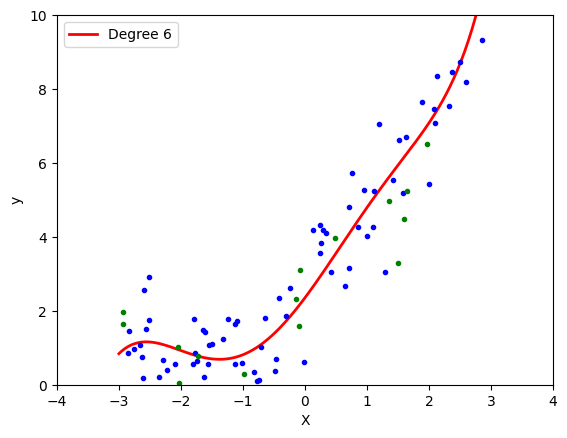

In [28]:
poly_regression(6)